# Compare FOV-level aggregation targets: median vs frac_ge075

Given single-cell `mean_osc_probability`, compute two FOV-level aggregation targets, fit a separate BO for each, and compare them head-to-head on the **same** underlying data.

Targets:
- `median` = 50th percentile of per-cell `mean_osc_probability` per FOV
- `frac_ge075` = fraction of cells in a FOV with `mean_osc_probability >= 0.75`

These two were the highest-fold-change targets in the inspection notebook.

In [1]:
import os, importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# gpax/numpyro compat shim
import numpyro.contrib.module as _ncm


def _haiku_unavailable(*_a, **_k):
    raise NotImplementedError("haiku removed")


if not hasattr(_ncm, "random_haiku_module"):
    _ncm.random_haiku_module = _haiku_unavailable
if not hasattr(_ncm, "haiku_module"):
    _ncm.haiku_module = _haiku_unavailable

RUN_PATH = r"E:\Alex\2026-04-10_bo_erk_oscillation_v4_test"
EXP_DATA_PATH = os.path.join(RUN_PATH, "exp_data.parquet")

N_FRAMES_BASELINE = 10
N_FRAMES_STIM = 60
N_FRAMES_RECOVERY = 20
N_FRAMES = N_FRAMES_BASELINE + N_FRAMES_STIM + N_FRAMES_RECOVERY
FIRST_FRAME_STIM = N_FRAMES_BASELINE
LAST_FRAME_STIM = FIRST_FRAME_STIM + N_FRAMES_STIM

CLASSIFIER_PATH = r"./oscillation_model_60min.joblib"
CLASSIFIER_SCRIPT = r"./apply_oscillation_classifier_v2.py"

In [2]:
import joblib

model_data = joblib.load(CLASSIFIER_PATH)
osc_clf = model_data["clf"]
osc_scaler = model_data["scaler"]
osc_feature_cols = model_data["feature_cols"]
osc_cfg = model_data["config"]
osc_cfg["window_size"] = model_data["window_size"]
osc_cfg["window_step"] = model_data["window_step"]

_spec = importlib.util.spec_from_file_location("osc_clf_mod", CLASSIFIER_SCRIPT)
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
predict_trace = _mod.predict_trace

df_exp = pd.read_parquet(EXP_DATA_PATH)
cond_map_df = (
    df_exp.groupby(["phase_id", "fov"])
    .agg(
        phase_name=("phase_name", "first"),
        stim_exposure=("stim_exposure", "first"),
        ramp=("ramp", "first"),
    )
    .reset_index()
)
phases = sorted(df_exp["phase_id"].unique())
print(
    f"Loaded {len(df_exp)} rows, {len(phases)} phases, {df_exp['fov'].nunique()} FOVs"
)

Loaded 688761 rows, 9 phases, 162 FOVs


## Preprocess single-cell + FOV-level data once

In [3]:
from faro.agents.bo_optimization import BO_Parameter, BO_Objective, BO_Covariate
from faro.agents.bo_oscillation import OscillationBO
from faro.agents.bo_oscillation_single_cell import OscillationBOSingleCell

# Shared config used for all agents
bo_params = [
    BO_Parameter(name="stim_exposure", bounds=(50.0, 500.0), spacing=25.0),
    BO_Parameter(name="ramp", bounds=(0.0, 20.0), spacing=5.0),
]

shared_kwargs = dict(
    n_frames=N_FRAMES,
    first_frame_stim=FIRST_FRAME_STIM,
    last_frame_stim=LAST_FRAME_STIM,
    time_between_timesteps=60,
    imaging_channels=(),
    stim_channel=None,
    optocheck_channel=None,
    osc_clf=osc_clf,
    osc_scaler=osc_scaler,
    osc_feature_cols=osc_feature_cols,
    osc_cfg=osc_cfg,
    osc_predict_fn=predict_trace,
    min_osc_probability=0.0,
    min_consecutive_windows=0,
    min_fft_amplitude=0.0,
    n_baseline_frames=N_FRAMES_BASELINE,
    parameters_to_optimize=bo_params,
    n_iterations=len(phases),
    n_conditions_per_iter=2,
    n_initial_phases=2,
    acquisition_function="ei",
    n_cov_samples=20,
    ei_xi=0.2,
    ei_xi_final=0.01,
    ei_xi_decay_fraction=0.7,
    plot_live=False,
    save_checkpoints=False,
    verbose=False,
)

# Single-cell agent used only for its _preprocess_results (produces per-cell table)
_pre_agent = OscillationBOSingleCell(
    storage_path=os.path.join(RUN_PATH, "replay_quantile_pre"),
    gp_backend="vi_sparse",
    inducing_points_ratio=0.1,
    num_svi_steps=10,
    svi_step_size=5e-3,
    gp_batch_size=2000,
    density_k_neighbours=5,
    bo_covariates=[
        BO_Covariate(name="baseline_cnr"),
        BO_Covariate(name="optortk_expression", log_scale=True),
        BO_Covariate(name="mean_dist_k_nearest"),
    ],
    objective_metric=BO_Objective(name="mean_osc_probability", goal="maximize"),
    **shared_kwargs,
)
os.makedirs(_pre_agent.storage_path, exist_ok=True)
_pre_agent._ensure_results_df()

# FOV-level agent only for its _preprocess_results (FOV metadata)
_fov_pre = OscillationBO(
    storage_path=os.path.join(RUN_PATH, "replay_quantile_fov_pre"),
    bo_covariates=[
        BO_Covariate(name="baseline_cnr"),
        BO_Covariate(name="optortk_expression", log_scale=True),
        BO_Covariate(name="n_cells"),
    ],
    objective_metric=BO_Objective(name="mean_osc_probability", goal="maximize"),
    **shared_kwargs,
)
os.makedirs(_fov_pre.storage_path, exist_ok=True)
_fov_pre._ensure_results_df()

all_cell_rows, all_fov_rows = [], []
for phase_id in phases:
    df_phase_raw = df_exp[df_exp["phase_id"] == phase_id]
    fov_tracks = {
        int(fov): df_phase_raw[df_phase_raw["fov"] == fov].copy()
        for fov in df_phase_raw["fov"].unique()
    }
    cm = cond_map_df[cond_map_df["phase_id"] == phase_id]
    cond_map = {
        int(row["fov"]): dict(
            stim_exposure=float(row["stim_exposure"]), ramp=float(row["ramp"])
        )
        for _, row in cm.iterrows()
    }
    _pre_agent._current_condition_map = cond_map
    _pre_agent._current_phase_id = int(phase_id)
    df_cell = _pre_agent._preprocess_results(fov_tracks)
    if not df_cell.empty:
        all_cell_rows.append(df_cell)

    _fov_pre._current_condition_map = cond_map
    _fov_pre._current_phase_id = int(phase_id)
    df_fov = _fov_pre._preprocess_results(fov_tracks)
    if not df_fov.empty:
        all_fov_rows.append(df_fov)

df_cells = pd.concat(all_cell_rows, ignore_index=True)
df_fovs = pd.concat(all_fov_rows, ignore_index=True)

# Attach phase_name to df_cells and df_fovs
name_map = cond_map_df[["phase_id", "fov", "phase_name"]]
df_cells = df_cells.merge(name_map, on=["phase_id", "fov"], how="left")
df_fovs = df_fovs.merge(name_map, on=["phase_id", "fov"], how="left")

# Drop rows with non-positive optortk_expression (log-scale requires > 0)
df_cells = df_cells[df_cells["optortk_expression"] > 0].reset_index(drop=True)
df_fovs = df_fovs[df_fovs["optortk_expression"] > 0].reset_index(drop=True)

print(f"df_cells: {len(df_cells)} cells across {df_cells['phase_id'].nunique()} phases")
print(f"df_fovs:  {len(df_fovs)} FOVs across {df_fovs['phase_id'].nunique()} phases")
print(
    f"\nPer-FOV cell count stats: mean={df_cells.groupby(['phase_id','fov']).size().mean():.1f}, "
    f"min={df_cells.groupby(['phase_id','fov']).size().min()}, "
    f"max={df_cells.groupby(['phase_id','fov']).size().max()}"
)

  Phase 0: 655 cells (from 18 FOVs), mean mean_osc_probability=0.1092, max=0.9960
  Phase 0: 18 FOVs, mean frac_oscillating=1.0000, max=1.0000
  Phase 1: 285 cells (from 17 FOVs), mean mean_osc_probability=0.1577, max=0.9805
  Phase 1: 12 FOVs, mean frac_oscillating=1.0000, max=1.0000
  Phase 2: 677 cells (from 18 FOVs), mean mean_osc_probability=0.1794, max=0.9969
  Phase 2: 18 FOVs, mean frac_oscillating=0.9986, max=1.0000
  Phase 3: 435 cells (from 18 FOVs), mean mean_osc_probability=0.2145, max=0.9926
  Phase 3: 18 FOVs, mean frac_oscillating=1.0000, max=1.0000
  Phase 4: 409 cells (from 18 FOVs), mean mean_osc_probability=0.2393, max=0.9976
  Phase 4: 17 FOVs, mean frac_oscillating=1.0000, max=1.0000
  Phase 5: 551 cells (from 18 FOVs), mean mean_osc_probability=0.1955, max=0.9980
  Phase 5: 18 FOVs, mean frac_oscillating=1.0000, max=1.0000
  Phase 6: 444 cells (from 18 FOVs), mean mean_osc_probability=0.2820, max=0.9901
  Phase 6: 18 FOVs, mean frac_oscillating=1.0000, max=1.0000

## Compute the two aggregation targets per FOV

In [4]:
# Aggregate per-cell mean_osc_probability to FOV-level: median and frac_ge075
targets = (
    df_cells.groupby(["phase_id", "fov"])["mean_osc_probability"]
    .agg(
        median=lambda s: s.quantile(0.50),
        frac_ge075=lambda s: float((s >= 0.75).mean()),
    )
    .reset_index()
)

df_fovs_q = df_fovs.merge(targets, on=["phase_id", "fov"], how="left")
df_fovs_q = df_fovs_q.dropna(subset=["median", "frac_ge075"]).reset_index(drop=True)

print(
    df_fovs_q[
        ["phase_id", "fov", "stim_exposure", "ramp", "median", "frac_ge075", "n_cells"]
    ].head(10)
)

# Signal-to-noise: between-phase std vs within-phase std
for tgt in ["median", "frac_ge075"]:
    within = df_fovs_q.groupby("phase_id")[tgt].std().mean()
    between = df_fovs_q.groupby("phase_id")[tgt].mean().std()
    print(
        f"\n{tgt:12s}: between-phase std = {between:.4f}, "
        f"within-phase std = {within:.4f}, S/N = {between/max(within,1e-9):.3f}"
    )

   phase_id  fov  stim_exposure  ramp    median  frac_ge075  n_cells
0         0    0           75.0  15.0  0.017595    0.012195     82.0
1         0   10          500.0   0.0  0.021842    0.052632     58.0
2         0   11          500.0   0.0  0.012042    0.000000     23.0
3         0   12          500.0   0.0  0.107327    0.125000     24.0
4         0   13          500.0   0.0  0.053292    0.024390     41.0
5         0   14          500.0   0.0  0.030249    0.000000     34.0
6         0   15          500.0   0.0  0.120731    0.101449     70.0
7         0   16          500.0   0.0  0.031016    0.032787     62.0
8         0   17          500.0   0.0  0.004165    0.000000     21.0
9         0    1           75.0  15.0  0.004518    0.000000     44.0

median      : between-phase std = 0.0390, within-phase std = 0.0819, S/N = 0.476

frac_ge075  : between-phase std = 0.0307, within-phase std = 0.0668, S/N = 0.459


## Distribution of each target — are they saturating?

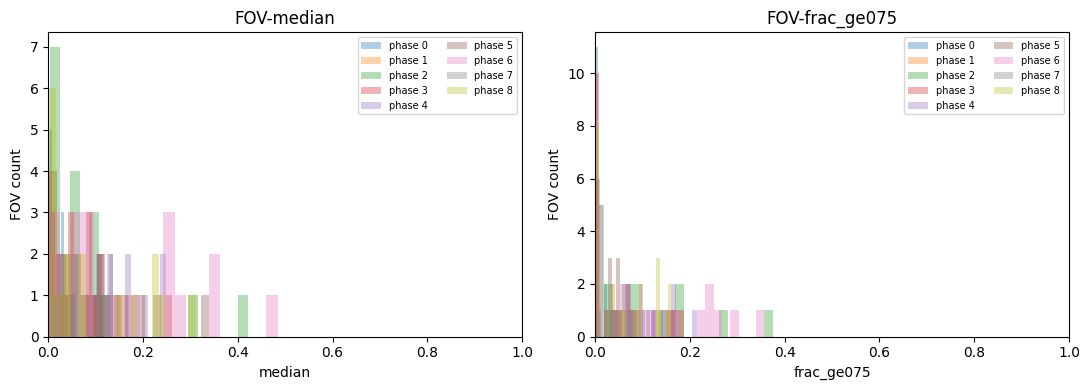

median      : 31/153 near 0, 0/153 near 1
frac_ge075  : 60/153 near 0, 0/153 near 1


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, tgt in zip(axes, ["median", "frac_ge075"]):
    for pid in phases:
        vals = df_fovs_q[df_fovs_q["phase_id"] == pid][tgt]
        ax.hist(vals, bins=20, alpha=0.35, label=f"phase {pid}")
    ax.set_title(f"FOV-{tgt}")
    ax.set_xlabel(tgt)
    ax.set_ylabel("FOV count")
    ax.set_xlim(0, 1)
    ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

for tgt in ["median", "frac_ge075"]:
    n_zero = (df_fovs_q[tgt] < 0.01).sum()
    n_one = (df_fovs_q[tgt] > 0.99).sum()
    print(
        f"{tgt:12s}: {n_zero}/{len(df_fovs_q)} near 0, {n_one}/{len(df_fovs_q)} near 1"
    )

## Fit 2 BO agents (gpax ExactGP+MCMC), one per target

In [6]:
bo_covariates_fov = [
    BO_Covariate(name="baseline_cnr"),
    BO_Covariate(name="optortk_expression", log_scale=True),
    BO_Covariate(name="n_cells"),
]


def _make_agent(target_name, storage_sub):
    a = OscillationBO(
        storage_path=os.path.join(RUN_PATH, storage_sub),
        bo_covariates=bo_covariates_fov,
        objective_metric=BO_Objective(name=target_name, goal="maximize"),
        **shared_kwargs,
    )
    os.makedirs(a.storage_path, exist_ok=True)
    df = df_fovs_q.copy()
    a.df_results = df
    a.iteration = len(phases) - 1
    a._last_plot_context = None
    return a


agent_p50 = _make_agent("median", "replay_quantile_p50")
agent_frac = _make_agent("frac_ge075", "replay_quantile_frac_ge075")

print("Fitting median...")
params_p50 = agent_p50._determine_next_parameters(agent_p50.df_results, verbose=False)
print("\nFitting frac_ge075...")
params_frac = agent_frac._determine_next_parameters(
    agent_frac.df_results, verbose=False
)

print(f"\nNext pick - median:     {params_p50}")
print(f"Next pick - frac_ge075: {params_frac}")

Fitting median...


sample: 100%|██████████| 1200/1200 [00:12<00:00, 94.36it/s, 7 steps of size 3.08e-01. acc. prob=0.92]  



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.32      1.87      0.70      0.02      3.24    606.58      1.00
k_length[1]      1.49      1.63      0.95      0.05      3.22    378.79      1.00
k_length[2]      0.90      1.59      0.48      0.02      1.96    396.55      1.00
k_length[3]      0.88      1.15      0.48      0.03      2.13    303.53      1.00
k_length[4]      2.10      2.19      1.37      0.11      4.52    423.92      1.00
    k_scale      0.41      0.21      0.38      0.05      0.70    214.29      1.00
      noise      0.66      0.22      0.68      0.31      1.01    203.58      1.00

Computing robust acquisition over 1900 scenarios (95 grid points x 20 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.348789
  Robust acq stats: min=0.037365, max=0.239677

Fitting frac_ge075...


sample: 100%|██████████| 1200/1200 [00:07<00:00, 153.80it/s, 7 steps of size 6.25e-01. acc. prob=0.82]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      2.11      2.77      1.47      0.16      4.24    811.64      1.00
k_length[1]      1.52      2.75      0.79      0.06      3.00    326.44      1.00
k_length[2]      0.99      0.99      0.70      0.06      1.95    630.68      1.00
k_length[3]      1.20      1.14      0.94      0.10      2.25    774.75      1.00
k_length[4]      1.83      2.00      1.17      0.09      3.92    405.43      1.00
    k_scale      0.28      0.14      0.25      0.06      0.49    538.40      1.00
      noise      0.80      0.14      0.80      0.59      1.03    379.47      1.00

Computing robust acquisition over 1900 scenarios (95 grid points x 20 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.174547
  Robust acq stats: min=0.042104, max=0.166367

Next pick - median:     {'stim_exposure': np.float64(375.0), 'ramp': np.float64(20.0)}
Next pick - frac_ge075: {'stim_exposure': np.float64(

## ARD lengthscales per target

In [7]:
dim_names = [p.name for p in agent_p50.parameters_to_optimize] + [
    c.name for c in agent_p50.bo_covariates
]

for agent, label in [(agent_p50, "median"), (agent_frac, "frac_ge075")]:
    ls = np.asarray(agent.model.get_samples()["k_length"])
    if ls.ndim > 1:
        ls = ls.mean(axis=0)
    ls = ls.squeeze()
    rel = 1.0 / ls
    rel /= rel.max()
    print(f"--- {label} ---")
    for n, l, r in sorted(zip(dim_names, ls, rel), key=lambda t: t[1]):
        print(f"  {n:28s}  ls={float(l):7.3f}  rel={float(r):.2f}")
    print()

--- median ---
  optortk_expression            ls=  0.877  rel=1.00
  baseline_cnr                  ls=  0.897  rel=0.98
  stim_exposure                 ls=  1.319  rel=0.66
  ramp                          ls=  1.488  rel=0.59
  n_cells                       ls=  2.096  rel=0.42

--- frac_ge075 ---
  baseline_cnr                  ls=  0.990  rel=1.00
  optortk_expression            ls=  1.204  rel=0.82
  ramp                          ls=  1.523  rel=0.65
  n_cells                       ls=  1.831  rel=0.54
  stim_exposure                 ls=  2.106  rel=0.47



## Training metrics + holdout generalisation

In [8]:
import gpax


def _predict_gpax(agent, X_raw):
    X_scaled = np.asarray(agent._x_scaler.transform(X_raw))
    rng = getattr(agent, "_rng_key_predict", None)
    if rng is None:
        _, rng = gpax.utils.get_keys()
    chunk = 2000
    means, vars_ = [], []
    for i in range(0, X_scaled.shape[0], chunk):
        Xb = X_scaled[i : i + chunk]
        mean_b, y_samp = agent.model.predict(rng, Xb, n=64, noiseless=True)
        y_samp = np.asarray(y_samp)
        y_flat = y_samp.reshape(-1, y_samp.shape[-1])
        means.append(np.asarray(mean_b).flatten())
        vars_.append(y_flat.var(axis=0))
    mean_s = np.concatenate(means)
    var_s = np.concatenate(vars_)
    mean = agent._y_scaler.inverse_transform(mean_s.reshape(-1, 1)).flatten()
    std = np.sqrt(np.maximum(var_s, 1e-12)) * float(
        np.abs(np.asarray(agent._y_scaler.std_)[0])
    )
    return mean, std


def _metrics(agent, df):
    cols = [p.name for p in agent.parameters_to_optimize] + [
        c.name for c in agent.bo_covariates
    ]
    y = df[agent.objective_metric.name].to_numpy(dtype=float)
    X = df[cols].to_numpy(dtype=float)
    m, s = _predict_gpax(agent, X)
    resid = y - m
    r2 = 1 - float(np.sum(resid**2)) / max(float(np.sum((y - y.mean()) ** 2)), 1e-12)
    rmse = float(np.sqrt(np.mean(resid**2)))
    nlpd = float(np.mean(0.5 * np.log(2 * np.pi * s**2) + 0.5 * (resid**2) / (s**2)))
    cov = float(np.mean((y >= m - 1.96 * s) & (y <= m + 1.96 * s)))
    z_std = float(np.std(resid / np.maximum(s, 1e-12)))
    return dict(
        r2=r2, rmse=rmse, nlpd=nlpd, coverage=cov, z_std=z_std, mean=m, std=s, y=y
    )


train = {}
for agent, label in [(agent_p50, "median"), (agent_frac, "frac_ge075")]:
    train[label] = _metrics(agent, df_fovs_q)

train_summary = pd.DataFrame(
    {
        label: [train[label][k] for k in ("r2", "rmse", "nlpd", "coverage", "z_std")]
        for label in ("median", "frac_ge075")
    },
    index=["R2", "RMSE", "NLPD", "95% coverage", "z-score std"],
)
print("=== Training metrics ===")
print(train_summary.round(4))
print(
    f"\ntarget stds: median={df_fovs_q['median'].std():.4f}, "
    f"frac_ge075={df_fovs_q['frac_ge075'].std():.4f}"
)

=== Training metrics ===
              median  frac_ge075
R2            0.5753      0.3619
RMSE          0.0612      0.0612
NLPD         -1.5368     -0.7993
95% coverage  0.9150      0.7647
z-score std   1.1525      1.8915

target stds: median=0.0942, frac_ge075=0.0769


Holdout phase 8: train n=136, test n=17


sample: 100%|██████████| 1200/1200 [00:07<00:00, 154.67it/s, 7 steps of size 4.47e-01. acc. prob=0.85]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.26      2.04      0.57      0.02      2.96    664.80      1.00
k_length[1]      1.09      1.42      0.69      0.06      2.15    411.45      1.00
k_length[2]      0.76      0.93      0.51      0.03      1.55    455.51      1.00
k_length[3]      1.61      1.75      1.13      0.07      3.24    451.54      1.00
k_length[4]      2.51      2.59      1.76      0.04      5.28    410.52      1.00
    k_scale      0.37      0.20      0.33      0.08      0.69    347.61      1.00
      noise      0.72      0.18      0.73      0.47      1.04    275.98      1.00

Computing robust acquisition over 1880 scenarios (94 grid points x 20 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.278337
  Robust acq stats: min=0.044764, max=0.214847


sample: 100%|██████████| 1200/1200 [00:07<00:00, 157.66it/s, 7 steps of size 4.08e-01. acc. prob=0.90] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      2.14      2.15      1.45      0.05      4.61    564.30      1.00
k_length[1]      0.85      1.16      0.46      0.02      1.98    486.25      1.00
k_length[2]      1.00      1.08      0.69      0.12      2.00    359.17      1.02
k_length[3]      1.24      1.17      0.90      0.08      2.48    605.64      1.00
k_length[4]      1.74      2.01      1.10      0.08      3.87    489.72      1.00
    k_scale      0.30      0.16      0.26      0.05      0.53    423.88      1.00
      noise      0.78      0.16      0.79      0.50      1.03    380.12      1.00

Computing robust acquisition over 1880 scenarios (94 grid points x 20 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.201349
  Robust acq stats: min=0.032327, max=0.170017

=== Holdout metrics ===
              median  frac_ge075
R2           -0.0215      0.0233
RMSE          0.1025      0.0616
NLPD         -0.0

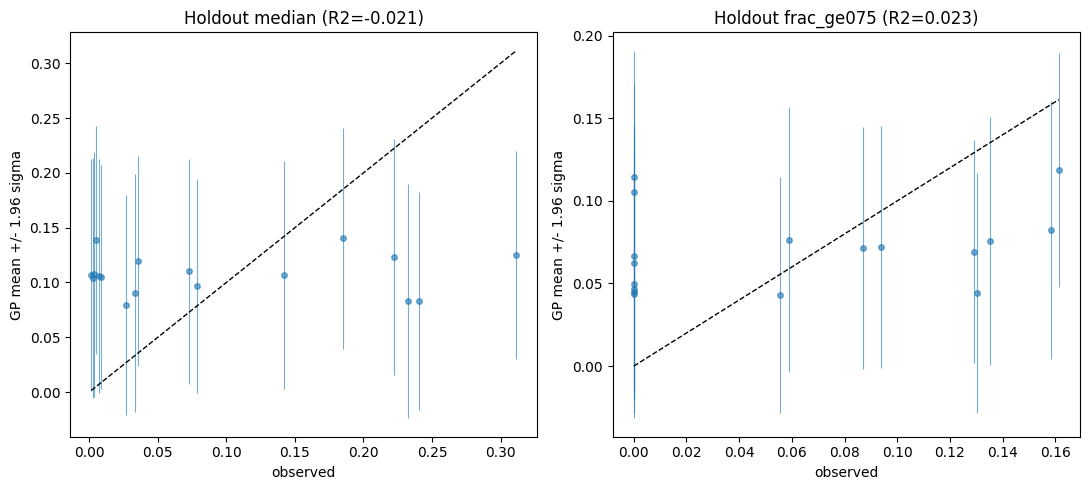

In [9]:
HOLDOUT_PHASE = max(phases)
df_tr = df_fovs_q[df_fovs_q["phase_id"] != HOLDOUT_PHASE]
df_te = df_fovs_q[df_fovs_q["phase_id"] == HOLDOUT_PHASE]
print(f"Holdout phase {HOLDOUT_PHASE}: train n={len(df_tr)}, test n={len(df_te)}")

holdout = {}
for agent, label in [(agent_p50, "median"), (agent_frac, "frac_ge075")]:
    agent.df_results = df_tr.copy()
    agent._last_plot_context = None
    _ = agent._determine_next_parameters(df_tr, verbose=False)
    holdout[label] = _metrics(agent, df_te)

hold_summary = pd.DataFrame(
    {
        label: [holdout[label][k] for k in ("r2", "rmse", "nlpd", "coverage", "z_std")]
        for label in ("median", "frac_ge075")
    },
    index=["R2", "RMSE", "NLPD", "95% coverage", "z-score std"],
)
print("\n=== Holdout metrics ===")
print(hold_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, label in zip(axes, ("median", "frac_ge075")):
    d = holdout[label]
    ax.errorbar(
        d["y"], d["mean"], yerr=1.96 * d["std"], fmt="o", alpha=0.6, ms=4, lw=0.8
    )
    lo = min(d["y"].min(), d["mean"].min())
    hi = max(d["y"].max(), d["mean"].max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set_title(f"Holdout {label} (R2={d['r2']:.3f})")
    ax.set_xlabel("observed")
    ax.set_ylabel("GP mean +/- 1.96 sigma")
plt.tight_layout()
plt.show()

## GP-predicted landscape per target

sample: 100%|██████████| 1200/1200 [00:13<00:00, 91.66it/s, 7 steps of size 3.08e-01. acc. prob=0.92]  



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.32      1.87      0.70      0.02      3.24    606.58      1.00
k_length[1]      1.49      1.63      0.95      0.05      3.22    378.79      1.00
k_length[2]      0.90      1.59      0.48      0.02      1.96    396.55      1.00
k_length[3]      0.88      1.15      0.48      0.03      2.13    303.53      1.00
k_length[4]      2.10      2.19      1.37      0.11      4.52    423.92      1.00
    k_scale      0.41      0.21      0.38      0.05      0.70    214.29      1.00
      noise      0.66      0.22      0.68      0.31      1.01    203.58      1.00

Computing robust acquisition over 1860 scenarios (93 grid points x 20 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.162697
  Robust acq stats: min=0.065645, max=0.203070


sample: 100%|██████████| 1200/1200 [00:07<00:00, 151.25it/s, 7 steps of size 6.25e-01. acc. prob=0.82]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      2.11      2.77      1.47      0.16      4.24    811.64      1.00
k_length[1]      1.52      2.75      0.79      0.06      3.00    326.44      1.00
k_length[2]      0.99      0.99      0.70      0.06      1.95    630.68      1.00
k_length[3]      1.20      1.14      0.94      0.10      2.25    774.75      1.00
k_length[4]      1.83      2.00      1.17      0.09      3.92    405.43      1.00
    k_scale      0.28      0.14      0.25      0.06      0.49    538.40      1.00
      noise      0.80      0.14      0.80      0.59      1.03    379.47      1.00

Computing robust acquisition over 1860 scenarios (93 grid points x 20 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.158593
  Robust acq stats: min=0.049745, max=0.177331


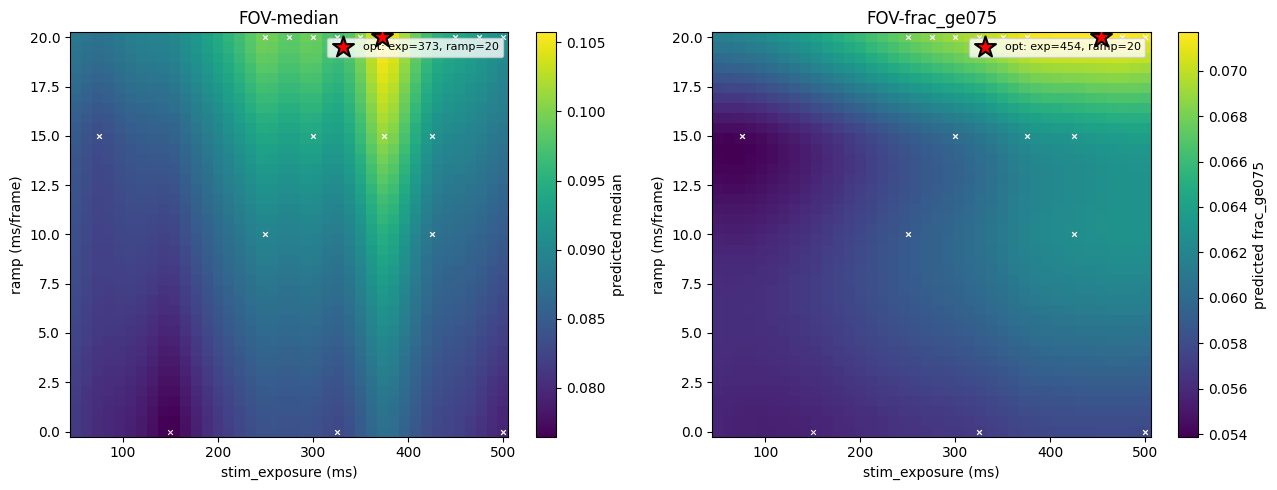

In [10]:
# Refit each on FULL data so landscape uses everything
for agent in (agent_p50, agent_frac):
    agent.df_results = df_fovs_q.copy()
    agent._last_plot_context = None
    _ = agent._determine_next_parameters(df_fovs_q, verbose=False)

grid_n = 40
x0_vals = np.linspace(50.0, 500.0, grid_n)
x1_vals = np.linspace(0.0, 20.0, grid_n)
X0, X1 = np.meshgrid(x0_vals, x1_vals, indexing="ij")
ctrl_grid = np.column_stack([X0.ravel(), X1.ravel()])
rng = np.random.default_rng(0)
n_mc = 50
cov_cols = [c.name for c in bo_covariates_fov]
cov_vals = df_fovs_q[cov_cols].to_numpy(dtype=float)
cov_samples = cov_vals[rng.integers(0, cov_vals.shape[0], size=n_mc)]
x_full = np.hstack(
    [np.repeat(ctrl_grid, n_mc, axis=0), np.tile(cov_samples, (ctrl_grid.shape[0], 1))]
)


def _landscape(agent):
    m, _ = _predict_gpax(agent, x_full)
    return m.reshape(ctrl_grid.shape[0], n_mc).mean(axis=1).reshape(grid_n, grid_n)


Z50 = _landscape(agent_p50)
Zfrac = _landscape(agent_frac)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, Z, label in zip(axes, [Z50, Zfrac], ("median", "frac_ge075")):
    im = ax.pcolormesh(X0, X1, Z, cmap="viridis", shading="auto")
    fig.colorbar(im, ax=ax, label=f"predicted {label}")
    ax.scatter(
        df_fovs_q["stim_exposure"],
        df_fovs_q["ramp"],
        c="white",
        s=12,
        alpha=0.5,
        marker="x",
        linewidths=0.5,
    )
    opt_i = int(np.argmax(Z))
    ax.scatter(
        X0.ravel()[opt_i],
        X1.ravel()[opt_i],
        c="red",
        s=250,
        marker="*",
        edgecolors="black",
        linewidths=1.5,
        zorder=10,
        label=f"opt: exp={X0.ravel()[opt_i]:.0f}, ramp={X1.ravel()[opt_i]:.0f}",
    )
    ax.legend(loc="upper right", fontsize=8)
    ax.set_xlabel("stim_exposure (ms)")
    ax.set_ylabel("ramp (ms/frame)")
    ax.set_title(f"FOV-{label}")
plt.tight_layout()
plt.show()